In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Define any arbitrary 2D function
def f(x, y):
    return x**2+4*y**2

In [4]:
# Vectorize for plotting
X = np.linspace(-2, 2, 200)
Y = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(X, Y)
ZZ = np.vectorize(f)(XX, YY)

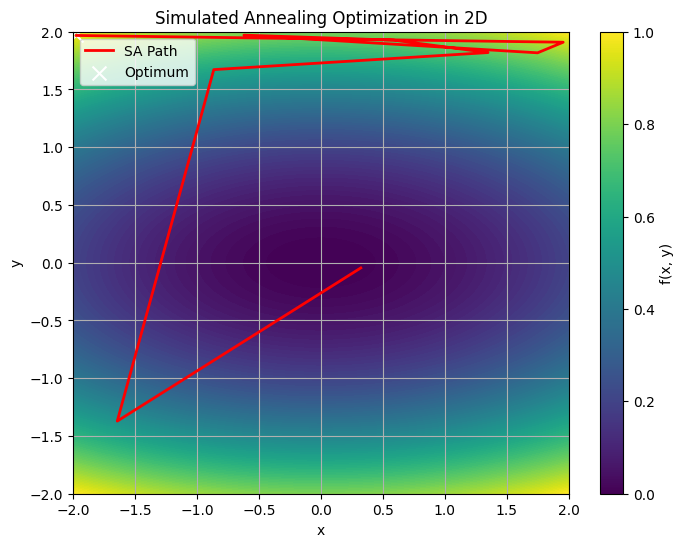

Optimal point found at: (np.float64(-1.9712853605049387), np.float64(1.9676456306166663)), f(x, y) = 19.37248328328052


In [6]:
# Simulated Annealing in 2D
def SA_2D(func, T=5, max_iter=1000):
    scale = np.sqrt(T)
    x, y = np.random.uniform(-2, 2), np.random.uniform(-2, 2)
    cur = func(x, y)
    history = [(x, y)]

    for i in range(max_iter):
        dx, dy = np.random.normal(scale=scale, size=2)
        x_prop, y_prop = x + dx, y + dy

        if not (-2 <= x_prop <= 2 and -2 <= y_prop <= 2):
            x_prop, y_prop = x, y

        new_val = func(x_prop, y_prop)
        if np.log(np.random.rand()) * T > new_val - cur:
            x_prop, y_prop = x, y
        else:
            cur = new_val

        x, y = x_prop, y_prop
        T *= 0.9
        history.append((x, y))
    
    return (x, y), history

# Run SA
opt_point, path = SA_2D(f, T=5)
path = np.array(path)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(XX, YY, ZZ, levels=100, cmap='viridis')
plt.plot(path[:, 0], path[:, 1], c='red', lw=2, label='SA Path')
plt.scatter(opt_point[0], opt_point[1], color='white', s=100, marker='x', label='Optimum')
plt.colorbar(label='f(x, y)')
plt.legend()
plt.title('Simulated Annealing Optimization in 2D')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

print(f"Optimal point found at: {opt_point}, f(x, y) = {f(*opt_point)}")